In [ ]:
## Customer Segmentation and Targeted Marketing for Telecom Operator

## Executive Summary

# This analysis aims to segment telecom customers based on usage, behavior, and devices to enable targeted marketing and 
# data driven decision making. We employed advanced clustering and feature engineering techniques to identify distinct 
# customer personas for actionable business strategies.



## Segment Summaries

'''ARPU - Average Revenue Per User'''

'''**Cluster 0 – “High data usage high data revenue”**'''
#- Above average ARPU, low voice usage n revenue
#- Highest ARPU, high main account balance, long tenure, mostly smartphone users.

'''**Cluster 1 – “Strong voice usage and voice revenue”**'''
#- Moderate ARPU, low data usage
#- Low tenure, high 4G/data usage, low voice usage, mostly new to the network.

'''**Cluster 2 – “Balanced across all features ”**'''
#- Moderate ARPU, Voice and Data usage
#- Frequent zero-balance days, low revenue, short tenure, many feature phone users.

'''**Cluster 3 – “Low data usage and Revenue”**'''
#- Low ARPU, Higher voice usage
#- Above average in voice calls, moderate balance, low data usage, mid-high tenure.

'''**Cluster 4 – “High data usage and revenue Similar to cluster 0”**'''
#- Moderate Voice usage , better ARPU than average, long tenure, mostly smartphone users.
#- Premium data users—engaged, high‑spending customers who are valuable for upselling.




C:\Users\paral\AppData\Local\Temp\ipykernel_7660\1072557929.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=data, palette='tab10')


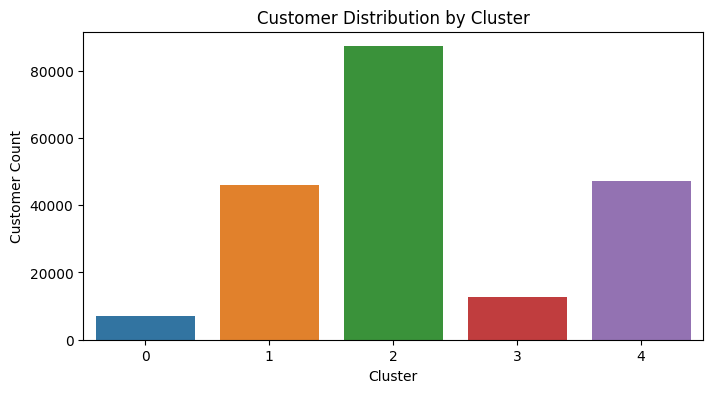

Cluster
0     6976
1    46032
2    87210
3    12641
4    47141
Name: count, dtype: int64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('../Data/cleaned_data2.csv')

plt.figure(figsize=(8, 4))
sns.countplot(x='Cluster', data=data, palette='tab10')
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.show()

print(data['Cluster'].value_counts().sort_index())


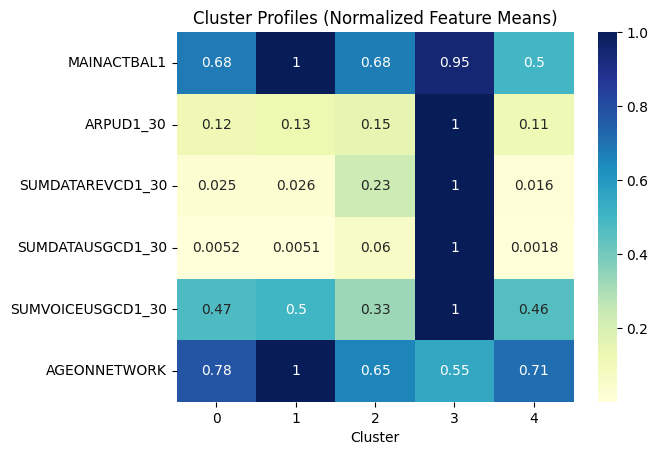

In [15]:
# Box plots for key features
key_numerical = ['MAINACTBAL1', 'ARPUD1_30', 'SUMDATAREVCD1_30', 
                 'SUMDATAUSGCD1_30', 'SUMVOICEUSGCD1_30', 'AGEONNETWORK']

# Heatmap of mean-normalized features by cluster
import numpy as np
features = key_numerical
#min_ = cluster_means.min()

min_ = 0
cluster_means = data.groupby('Cluster')[features].mean()
cluster_means_norm = (cluster_means - min_) / (cluster_means.max() - min_)
sns.heatmap(cluster_means_norm.T, annot=True, cmap='YlGnBu')
plt.title('Cluster Profiles (Normalized Feature Means)')
plt.show()


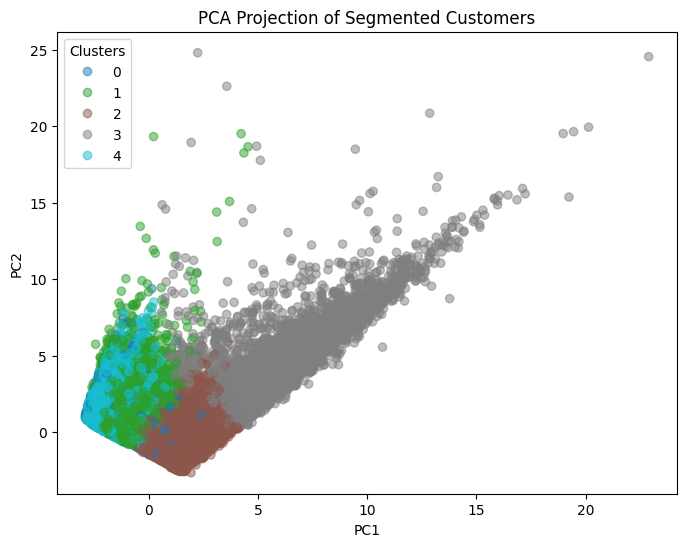

Explained variance ratio: [0.23621651 0.13083443]
Total variance explained: 0.36705094229122426


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_features = data.select_dtypes(include=[np.number]).drop('Cluster', axis=1)
scaler = StandardScaler()
num_scaled = scaler.fit_transform(num_features)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(num_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], 
                      c=data['Cluster'], cmap='tab10', alpha=0.5)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('PCA Projection of Segmented Customers')
plt.xlabel('PC1')
plt.ylabel('PC2')


#plt.scatter(pca_data[:, 0], pca_data[:, 1], c=data['Cluster'], cmap='tab10', alpha=0.5)
#plt.title('PCA Projection of Segmented Customers')
#plt.xlabel('PC1')
#plt.ylabel('PC2')
#plt.colorbar(label='Cluster')
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


#from sklearn.cluster import KMeans
#centers = pca.transform(scaler.transform(
#    data.drop('Cluster', axis=1).select_dtypes(include=[np.number])
#    .groupby(data['Cluster']).mean()
#))
#plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X')


In [6]:
summary = data.groupby('Cluster')[key_numerical].mean().reset_index()
display(summary)

,Cluster,MAINACTBAL1,ARPUD1_30,SUMDATAREVCD1_30,SUMDATAUSGCD1_30,SUMVOICEUSGCD1_30,AGEONNETWORK
0,0,10.316092,109.746560,0.272443,1.938031e+08,6920.321531,2081.653383
1,1,15.161974,119.478363,0.279213,1.869963e+08,7323.836462,2679.497415
2,2,10.240837,140.689416,2.519078,2.203191e+09,4749.989886,1750.265382
3,3,14.328487,930.377840,10.726414,3.702413e+10,14572.832134,1468.355193
4,4,7.579109,104.382788,0.168156,6.680398e+07,6724.698288,1900.997433
